In [148]:
import scanpy as scp
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np
import pandas as pd
import io
import os

from parameters import *

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [35]:
adata = scp.read("results/QC.h5ad")

/opt/conda/lib/python3.8/site-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


# Clustering

/opt/conda/lib/python3.8/site-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/opt/conda/lib/python3.8/site-packages/h5py/_hl/dataset.py:541: DeprecationWarning: Passing None into shape arguments as an alias for () is deprecated.
  arr = numpy.ndarray(selection.mshape, dtype=new_dtype)
/opt/conda/lib/python3.8/site-packages/h5py/_hl/dataset.py:541: DeprecationWarning: Passing None into shape arguments as an alias for () is deprecated.
  arr = numpy.ndarray(selection.mshape, dtype=new_dtype)
/opt/conda/lib/python3.8/site-packages/h5py/_hl/dataset.py:541: DeprecationWarning: Passing None into shape arguments as an alias for () is deprecated.
  arr = numpy.ndarray(selection.mshape, dtype=new_dtype)
/opt/conda/lib/pyth

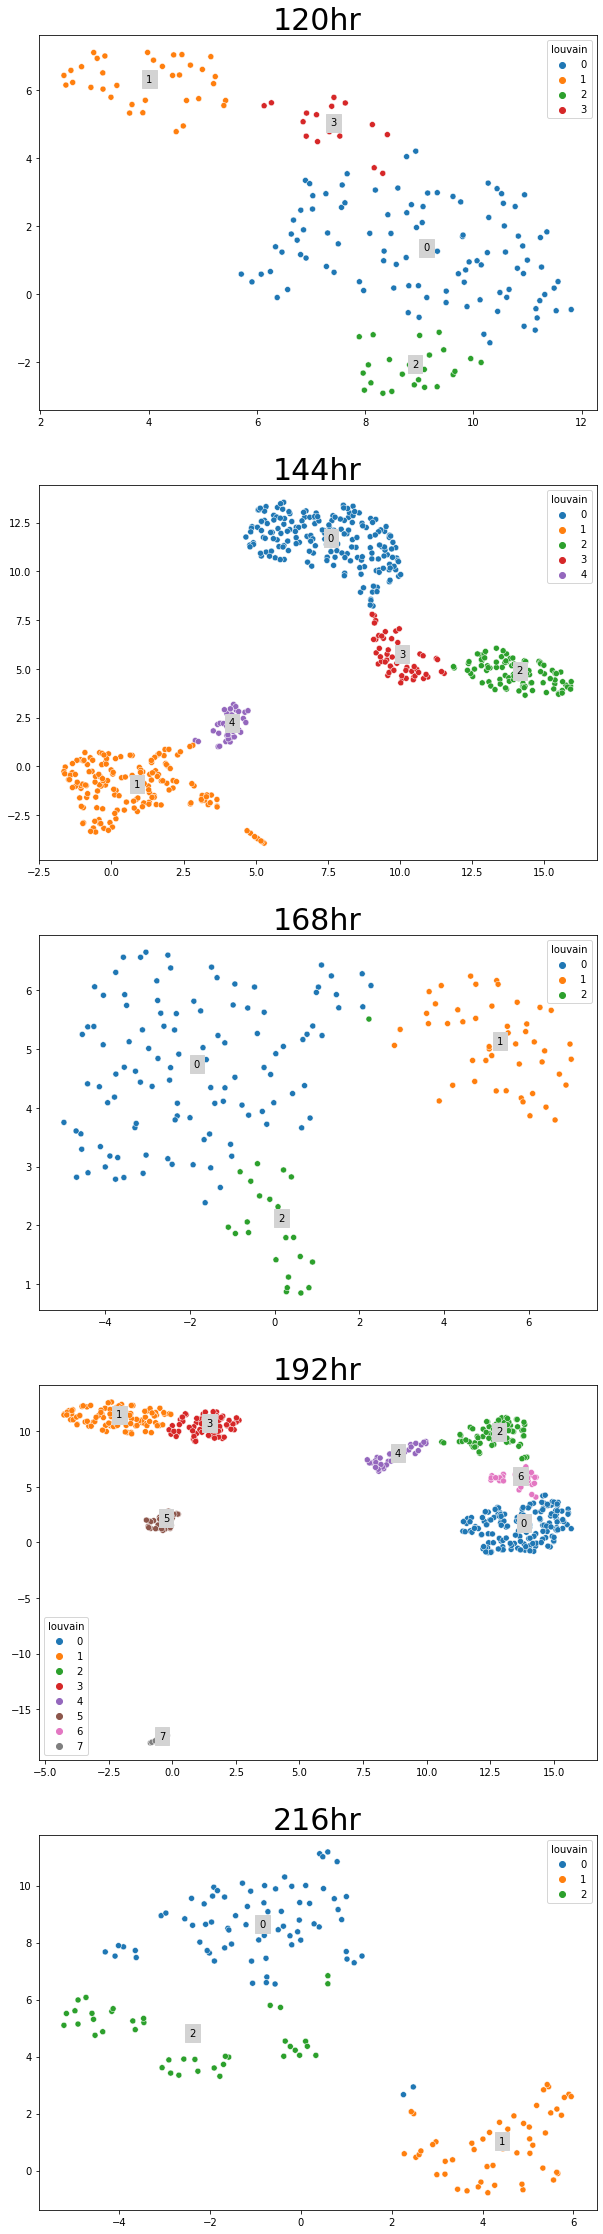

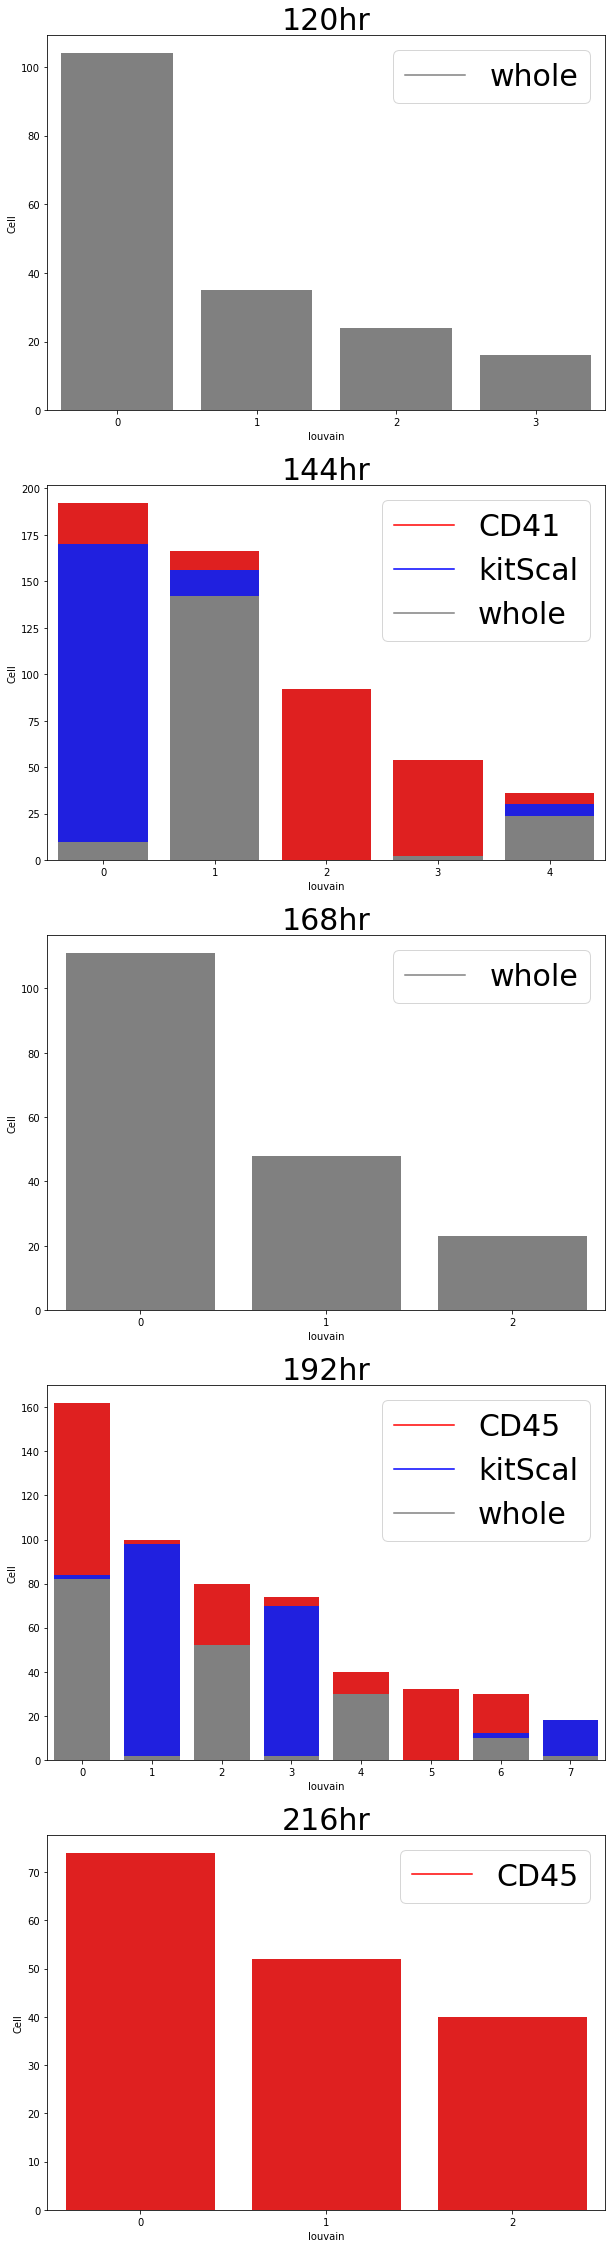

In [100]:
fig,ax = plt.subplots(5,1,figsize=[10,40])
fig2,ax2 = plt.subplots(5,1,figsize=[10,40])

pca = "X_pca"
umap = "X_umap"

for i,time in enumerate(np.sort(adata.obs["Time"].unique())):
    adataAux = scp.read("results/dimensional_reduction_"+time+".h5ad")
    
    scp.pp.neighbors(adataAux,use_rep=pca,metric=METRIC,n_pcs=PCA,knn=KNN)
    scp.tl.louvain(adataAux,resolution=RESOLUTION)
    
    #Scatter plots
    sns.scatterplot(x=adataAux.obsm[umap][:,0],y=adataAux.obsm[umap][:,1],hue=adataAux.obs["louvain"],ax=ax[i])
    ax[i].set_title(time,fontsize=30)   
    for louvain in adataAux.obs["louvain"].unique():
        x = adataAux[adataAux.obs["louvain"]==louvain,:].obsm[umap][:,0].mean()
        y = adataAux[adataAux.obs["louvain"]==louvain,:].obsm[umap][:,1].mean()
        ax[i].text(x,y,louvain,backgroundcolor="lightgrey")
    
    #Make cluster contributions by Condition
    data = adataAux.obs.groupby(by=["louvain","Condition"]).count()
    dCum = adataAux.obs.groupby(by=["louvain"]).count()
    color = {"whole":"grey","kitScal":"blue","CD41":"red","CD45":"red"}
    for j,condition in enumerate(data.index.unique(level=1)):
        
        d = data.xs(condition,level=1)
    
        sns.barplot(x=d.index,y=dCum["Cell"],color=color[condition],ax=ax2[i])

        dCum.loc[:,"Cell"] -= d.loc[:,"Cell"]
                
    ax2[i].set_title(time,fontsize=30)   
    ax2[i].legend(handles=[mlines.Line2D([],[],color=color[i],label=i) for i in data.index.unique(level=1)],fontsize=30)  

    #Make Condition contributions by  cluster
    
    adataAux.write("results/dimensional_reduction_"+time+".h5ad")    


# DE expression

In [191]:
genes = pd.read_excel("Marker_genes_scRNAseq_Gx.xlsx",header=None)

<ipython-input-191-2dff338aca04>:1: FutureWarning: Your version of xlrd is 1.2.0. In xlrd >= 2.0, only the xls format is supported. As a result, the openpyxl engine will be used if it is installed and the engine argument is not specified. Install openpyxl instead.
  genes = pd.read_excel("Marker_genes_scRNAseq_Gx.xlsx",header=None)


In [192]:
if not os.path.isdir("plots/DE_genes_umap"):
    os.mkdir("plots/DE_genes_umap")
    
not_found_genes = []
for gene in genes.values[:,0]:
        
    if gene in adata.var.loc[:,"gene_name"].values:
        fig,ax = plt.subplots(5,1,figsize=[10,40])
        
        for i,time in enumerate(np.sort(adata.obs["Time"].unique())):

            adataAux = scp.read("results/dimensional_reduction_"+time+".h5ad")

            sns.scatterplot(x=adataAux.obsm[umap][:,0],y=adataAux.obsm[umap][:,1],hue=np.array(adataAux[:,adataAux.var["gene_name"]==gene].X.todense())[:,0],ax=ax[i])
            ax[i].set_title(time,fontsize=30)  
            
        fig.savefig("plots/DE_genes_umap/"+gene+".png")
        plt.close(fig)
    else:
        not_found_genes.append(gene)
        
print("Not found genes: ",not_found_genes)

Not found genes:  ['Gfi1 ', 'Pax5']


In [188]:
if not os.path.isdir("tables"):
    os.mkdir("tables")

for j,time in enumerate(adata.obs["Time"].unique()[:]):

    adataAux = scp.read("results/dimensional_reduction_"+time+".h5ad")
    
    scp.tl.rank_genes_groups(adataAux,groupby="louvain",method="wilcoxon",use_raw=False)
    n_genes = 200
        
    writer = pd.ExcelWriter("tables/DE_"+time+".xlsx", engine='xlsxwriter')
    for k,group in enumerate(adataAux.uns["rank_genes_groups"]["names"].dtype.names):
            
        l = pd.DataFrame(columns=["names","logfoldchanges","pvals","pvals_adj","scores"])
        l.loc[:,"names"] = adataAux.var.loc[[n[k] for n in adataAux.uns["rank_genes_groups"]["names"]][:n_genes],"gene_name"].values
        l.loc[:,"logfoldchanges"] = [n[k] for n in adataAux.uns["rank_genes_groups"]["logfoldchanges"]][:n_genes]
        l.loc[:,"pvals"] = [n[k] for n in adataAux.uns["rank_genes_groups"]["pvals"]][:n_genes]
        l.loc[:,"pvals_adj"] = [n[k] for n in adataAux.uns["rank_genes_groups"]["pvals_adj"]][:n_genes]
        l.loc[:,"scores"] = [n[k] for n in adataAux.uns["rank_genes_groups"]["scores"]][:n_genes]
        
        l.to_excel(writer, sheet_name="cluster_"+str(k))
        
    writer.save()